# The Cicada-Brood effect — a quantitative teardown 🔬
### A one-sample-*t* battery across 24 independent emergence years · a season-controlled 20-seed random-year placebo · the May–June event anatomy · a beta-vs-alpha timer (excess over the every-spring baseline) · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cicada_indicator%3F: Busted](https://img.shields.io/badge/Cicada_indicator%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a fixed-calendar "cicada indicator" in the family of the Super Bowl predictor — has **no proposed mechanism**; it is on the desk precisely as a spurious-pattern control. The job here is to run the full apparatus honestly and confirm it returns nothing — including resisting the two traps (a >50% up-rate and a cherry-picked marquee subset) that would fool a careless reader.

> ⚠️ **Data note.** SPY **total-return** close (`auto_adjust=True`), yfinance, 1993-01-29 → 2026-06-30 (8,411 rows, cached); **30 hardcoded periodical-cicada emergences → 24 distinct emergence years** (UConn/Cooley brood chart). SPY is a real tradable instrument — **no proxy**. No survivorship (whole-market index; fixed astronomical schedule). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `a11dcd0a0a72`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cicada_brood import data, strategy as st

BROODS = data.brood_table()
EV_YEARS = data.brood_years()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY = data.load_real()
    RET = st.daily_returns(SPY)
    AR = st.abnormal_returns(RET)
    POOL = data.all_years(SPY)
else:
    SPY = RET = AR = POOL = None
print("real cache present:", HAVE_REAL, "| brood rows:", len(BROODS),
      "| distinct emergence years:", len(EV_YEARS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_broods': 30, 'cal_lo': 1996, 'cal_hi': 2025, 'n_events': 24, 'span': 30, 'brood_years_in_span': 24, 'pool_years': 33, 'spy_rows': 8411, 'K': 42, 'KS': 21, 'cut_all': (24, 2.4, 0.385, 0.37, 18, 24, 75, 55, 88), 'cut_17': (23, 2.626, 0.607, 0.57, 18, 23, 78, 58, 90), 'cut_fam': (5, 3.755, 1.706, 1.19, 5, 5, 100, 57, 100), 'baseline_bps': 180.1, 'cicada_mean_bps': 240.0, 'cicada_minus_base_bps': 60.0, 'placebo_obs_pct': 2.4, 'placebo_mean_pct': 1.802, 'placebo_sd_pct': 0.606, 'placebo_p': 0.165, 'placebo_draws': 20000, 'short_abn_pct': 0.142, 'short_abn_t': 0.2, 'welch_cicada_pct': 2.4, 'welch_non_pct': 0.201, 'welch_non_n': 9, 'welch_t': 0.874, 'anat': {0: (0.304, 1.52), 10: (0.517, 0.92), 21: (0.142, 0.2), 31: (0.444, 0.45), 42: (0.385, 0.37)}, 'timer_gross': (240.0, 75, 2.25, 60.0, 0.56), 'timer_net5': (230.0, 71, 2.15, 50.0, 0.47), 'timer_net10': (220.0, 71, 2.06, 40.0, 0.37), 'syn_null_mean': 0.15, 'syn_null_sd': 0.93, 'syn_null_fire': 1, 'syn_planted_t': 4.46, 'syn_planted_pct': 4.79, 'fp_spy': 'a11dcd0a0a72'}


real cache present: True | brood rows: 30 | distinct emergence years: 24


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | cicada-spring abnormal CAR **+0.39%**, one-sample **t = +0.37** (n=24), random-year placebo **p = 0.165**, Welch vs non-cicada springs t = +0.87 |
| **Tradability** | `MIRAGE` | timer excess over every-spring baseline **+60 bps gross, t = 0.56**; the +2.25 t-vs-zero is equity beta, not alpha |
| **Cicada indicator?** | `BUSTED` | a brood emerges in **24/30** years — the base rate alone kills it |

> 💡 In plain words: no mechanism, no signal, no edge — and the two things that *look* like evidence (a 75% up-rate, a 5/5 famous-brood streak) are drift and selection.

## 1 · The claim, steelmanned

Let $r_t$ be SPY's daily total return and $a_t = r_t - \bar{r}$ its abnormal return under a constant-mean market model (Brown & Warner 1985). For emergence year $i$, anchor $\tau_i$ = first session on/after May 1, window length $K = 42$ sessions. The claims:

- **H₁ (cicada springs are special).** $E\big[\sum_{k=0}^{K} a_{\tau_i+k}\big] > 0$ — a positive *abnormal* spring CAR, systematically across emergence years.
- **H₂ (beats a random spring).** The mean cicada-spring window return exceeds what a random calendar of the same number of springs produces.
- **H₃ (beats a quiet spring).** Cicada springs out-return non-cicada springs (Welch, same window).
- **H₄ (tradable).** A long-SPY cicada-spring overlay beats the unconditional every-spring baseline net of costs — *excess*, not raw.

We find **H₁ not supported** (t = +0.37), **H₂ not supported** (placebo p = 0.165), **H₃ not supported** (Welch t = +0.87), **H₄ not supported** (excess +60 bps, t = 0.56).

## 2 · So what? — inference design

Emergence years are **independent, non-overlapping** (one SPY spring each, years apart), so the planned primary is a **one-sample *t*** across the 24 per-year abnormal CARs — **not** a daily-panel regression, which would treat ~40 autocorrelated daily returns per event as independent and wildly overstate significance. Two traps are pre-empted by design: (i) the **up-rate carries a Wilson interval** and is read against the equity base rate, never against 50%; (ii) the **random-year placebo uses the same May–June window**, so the seasonal ("Sell in May") baseline cancels and the test isolates *cicada* springs from *random* springs. Tradability is graded on **excess over the every-spring baseline** (alpha), because a two-month equity window is positive on average for reasons unrelated to cicadas (beta).

## 3 · How we'd know — the protocol

- **Calendar.** 30 mapped emergences 1996–2025 → 24 distinct years (UConn/Cooley chart), hardcoded.
- **Tape.** SPY total-return close, 1993 → 2026-06-30 (as-of, last complete month), 8,411 rows, fingerprint `a11dcd0a0a72`.
- **Window.** Anchor = first session on/after May 1; K = 42 sessions (~2 months) headline, 21 (~1 month) cross-check.
- **Headline.** One-sample *t* on the abnormal CAR + Wilson up-rate + three cuts (all / 17-year-only / famous-marquee) to expose selection.
- **Placebo.** 20,000 random-year draws (20 seeds × 1,000), same window.
- **Contrast.** Welch cicada vs non-cicada springs.
- **Execution.** Zero look-ahead by construction (year known since the last emergence); enter last April close, exit ~end June; 2 × one-way cost × NAV; long-only; graded on excess over baseline.
- **Control.** Synthetic random-walk tape, planted spring bump; null must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · The headline and its season-controlled placebo

One-sample *t* on the per-year abnormal CAR, and the random-year null. In the notebook we run a lighter placebo (4 seeds × 500) and quote the canonical 20,000-draw *p* from `results.md`.

abnormal CAR +0.385%  one-sample t = +0.368  (n=24)


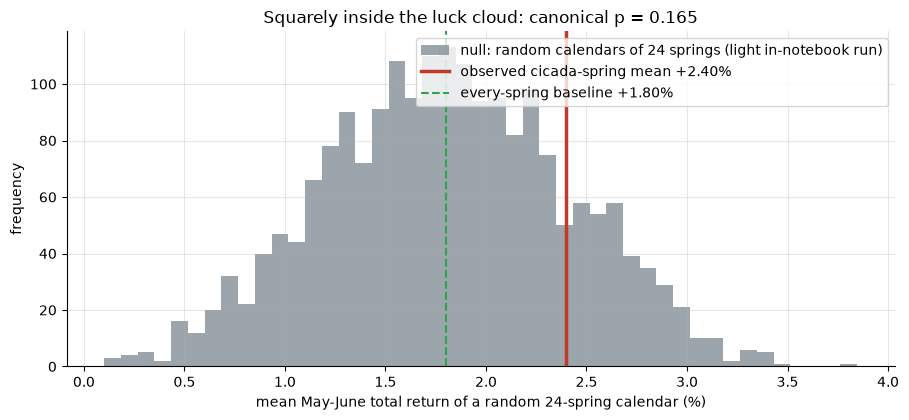

canonical placebo (results.md): mean +1.802%, sd 0.606%, right-tail p = 0.165


In [2]:
if HAVE_REAL:
    evt = st.build_event_table(SPY, AR, EV_YEARS, k=R['K'])
    s = st.one_sample_t(evt['abn_car'].to_numpy())
    obs_raw = float(evt['raw_ret'].mean())
    pl = st.random_year_placebo(SPY, POOL, n_events=len(EV_YEARS), k=R['K'],
                                 n_seeds=4, n_draws_per_seed=500, base_seed=741)
    draws = pl['means']
    print(f"abnormal CAR {s['mean']*100:+.3f}%  one-sample t = {s['t']:+.3f}  "
          f"(n={s['n']})")
else:
    obs_raw = R['placebo_obs_pct'] / 100
    rng = np.random.default_rng(741)
    draws = rng.normal(R['placebo_mean_pct']/100, R['placebo_sd_pct']/100, 2000)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(draws * 100, bins=45, color=GREY, alpha=.85,
        label='null: random calendars of 24 springs (light in-notebook run)')
ax.axvline(obs_raw * 100, c=RED, lw=2.5,
           label=f'observed cicada-spring mean {obs_raw*100:+.2f}%')
ax.axvline(R['baseline_pct'] if 'baseline_pct' in R else R['baseline_bps']/100,
           c=GREEN, ls='--', lw=1.5, label=f"every-spring baseline {R['baseline_bps']/100:+.2f}%")
ax.set_xlabel('mean May-June total return of a random 24-spring calendar (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Squarely inside the luck cloud: canonical p = {R['placebo_p']:.3f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean_pct']:+.3f}%, "
      f"sd {R['placebo_sd_pct']:.3f}%, right-tail p = {R['placebo_p']:.3f}")

> 💡 In plain words: the observed **+2.40%** sits just inside the right shoulder of the null (+1.80 ± 0.61%); **p = 0.165** — a random 24-spring calendar beats it about 1 time in 6. With abnormal-CAR t = **+0.37** and the 1-month window at t = **+0.20** (+0.14%), H₁ and H₂ are dead.

### 4b · Event anatomy — the May–June CAR path

Per-offset cumulative abnormal return from the May-1 anchor, each offset's own one-sample *t*. If cicadas mattered, the path would climb and a *t* would clear the bar somewhere. It doesn't.

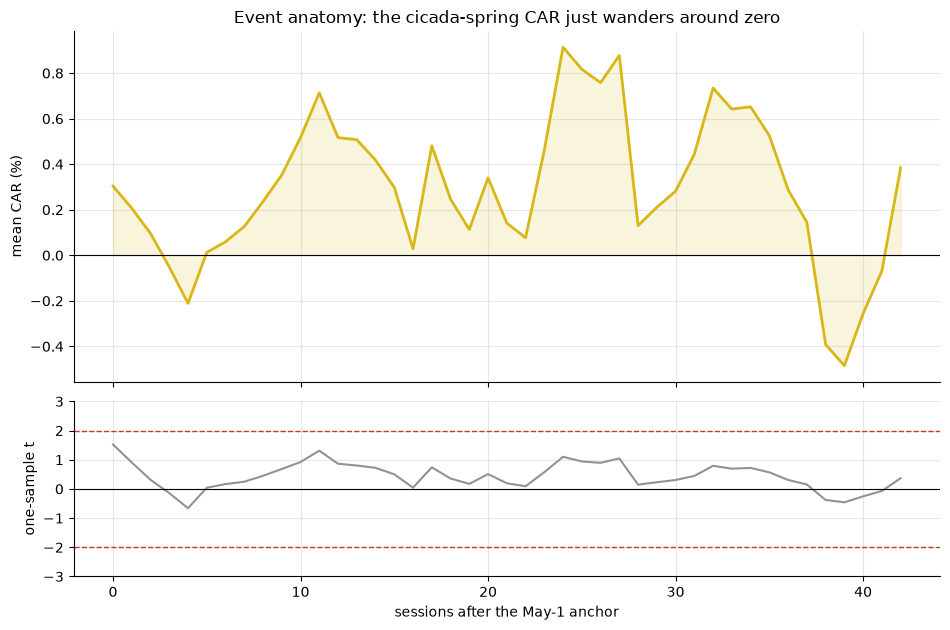

CAR% by offset: {0: 0.304, 10: 0.517, 21: 0.142, 31: 0.444, 42: 0.385}
max |t| along the path: 1.52


In [3]:
if HAVE_REAL:
    cp = st.car_path(SPY, AR, EV_YEARS, k=R['K'])
    ks = list(cp.index); cars = list(cp['car'] * 100); ts = list(cp['t'])
else:
    ks = sorted(R['anat']); cars = [R['anat'][k][0] for k in ks]
    ts = [R['anat'][k][1] for k in ks]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.6, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.plot(ks, cars, color=AMBER, lw=2); a1.axhline(0, c='k', lw=.8)
a1.fill_between(ks, 0, cars, color=AMBER, alpha=.15)
a1.set_ylabel('mean CAR (%)')
a1.set_title('Event anatomy: the cicada-spring CAR just wanders around zero')
a2.plot(ks, ts, color=GREY, lw=1.5)
a2.axhline(0, c='k', lw=.8)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.set_ylim(-3, 3); a2.set_ylabel('one-sample t')
a2.set_xlabel('sessions after the May-1 anchor')
plt.tight_layout(); plt.show()
print('CAR% by offset:', {k: round(c, 3) for k, c in zip(ks, cars) if k in (0,10,21,31,42)})
print('max |t| along the path:', round(max(abs(t) for t in ts), 2))

> 💡 In plain words: the CAR never gets more than a fraction of a percent from flat, and its *t* peaks at a forgettable **+1.52** on the very first in-window session, then fades. No offset clears |*t*| ≥ 2. There is no build-up, no peak, no shape — just a two-month random walk.

### 4c · The two traps — up-rate base rate & marquee selection

The results a careless believer would quote: the up-rate, and the famous-broods-only cut. Both are shown *with* their honest context.

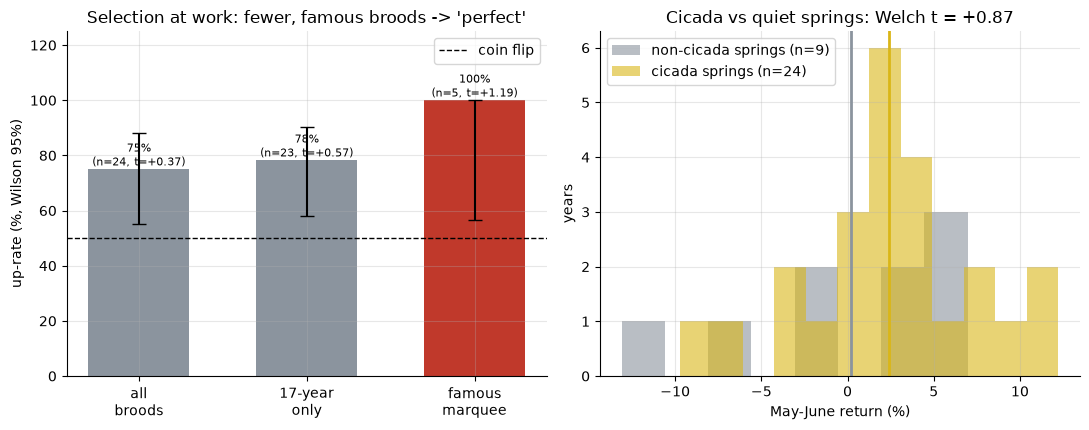

up-rates: [75, 78, 100] | abn-CAR t: [0.37, 0.57, 1.19]
Welch cicada-vs-non t = +0.874


In [4]:
labels = ['all\nbroods', '17-year\nonly', 'famous\nmarquee']
if HAVE_REAL:
    rows = []
    for yrs in (EV_YEARS, data.brood_years(cycle=17),
                data.brood_years(famous_only=True)):
        e = st.build_event_table(SPY, AR, yrs, k=R['K'])
        sa = st.one_sample_t(e['abn_car'].to_numpy())
        hr = st.hit_rate(e['raw_ret'].to_numpy())
        rows.append((hr['rate']*100, hr['lo']*100, hr['hi']*100, sa['t'], hr['n']))
    non = [y for y in POOL if y not in set(EV_YEARS)]
    wa = st.all_year_windows(SPY, POOL, k=R['K'])
    a = np.array([wa[y] for y in EV_YEARS if y in wa.index])
    b = np.array([wa[y] for y in non if y in wa.index])
    welch = st.welch_t(a, b)
else:
    rows = [(R['cut_all'][6], R['cut_all'][7], R['cut_all'][8], R['cut_all'][3], R['cut_all'][0]),
            (R['cut_17'][6], R['cut_17'][7], R['cut_17'][8], R['cut_17'][3], R['cut_17'][0]),
            (R['cut_fam'][6], R['cut_fam'][7], R['cut_fam'][8], R['cut_fam'][3], R['cut_fam'][0])]
    welch = R['welch_t']
rates = [r[0] for r in rows]; los = [r[0]-r[1] for r in rows]; his = [r[2]-r[0] for r in rows]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.bar(labels, rates, yerr=[los, his], capsize=5, color=[GREY, GREY, RED], width=.6)
a1.axhline(50, ls='--', c='k', lw=1, label='coin flip')
for i, r in enumerate(rows):
    a1.annotate(f'{r[0]:.0f}%\n(n={r[4]}, t={r[3]:+.2f})', (i, r[0]), ha='center', va='bottom', fontsize=8)
a1.set_ylim(0, 125); a1.set_ylabel('up-rate (%, Wilson 95%)')
a1.set_title('Selection at work: fewer, famous broods -> \'perfect\''); a1.legend()
if HAVE_REAL:
    a2.hist(b*100, bins=8, color=GREY, alpha=.6, label=f'non-cicada springs (n={len(b)})')
    a2.hist(a*100, bins=12, color=AMBER, alpha=.6, label=f'cicada springs (n={len(a)})')
    a2.axvline(a.mean()*100, c=AMBER, lw=2); a2.axvline(b.mean()*100, c=GREY, lw=2)
else:
    a2.text(.5, .5, 'cicada vs non-cicada springs', ha='center', transform=a2.transAxes)
a2.set_xlabel('May-June return (%)'); a2.set_ylabel('years')
a2.set_title(f'Cicada vs quiet springs: Welch t = {welch:+.2f}'); a2.legend()
plt.tight_layout(); plt.show()
print('up-rates:', [round(r[0]) for r in rows], '| abn-CAR t:', [round(r[3],2) for r in rows])
print(f'Welch cicada-vs-non t = {welch:+.3f}')

> 💡 In plain words: the all-broods up-rate is **75%** (Wilson [55%, 88%]) — wide, and sitting on an equity base rate that's already north of 50%. Slice to the 5 famous broods and it's **100% up** at t = +1.19: a pure small-sample selection mirage (5 fair coins land 5 heads ~1 in 32). And cicada springs don't beat quiet springs — Welch t = **+0.87**, underpowered anyway because only **9** of the last 33 springs were cicada-free.

### 4d · The timer — beta vs alpha

The tradability trap, made explicit. A one-sample *t* of the raw cicada-spring return vs **zero** looks significant — but that is just SPY's ordinary two-month drift. The edge, if any, is the **excess over the every-spring baseline**.

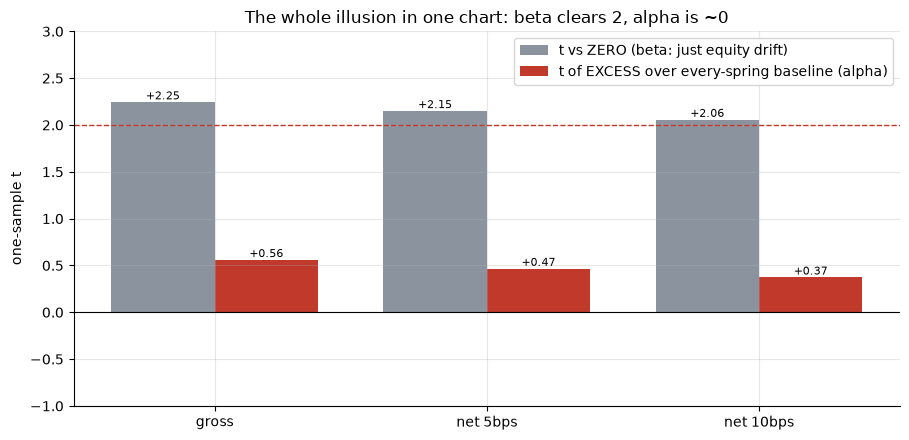

t vs zero (beta): [2.25, 2.15, 2.06]
excess bps: [60, 50, 40] | excess t (alpha): [0.56, 0.47, 0.37]


In [5]:
legs = ['gross', 'net 5bps', 'net 10bps']
if HAVE_REAL:
    tvs0, exc, exc_t = [], [], []
    for cost in (0.0, 5.0, 10.0):
        lg = st.spring_timer(SPY, EV_YEARS, k=R['K'], cost_bps=cost)
        col = 'ret_gross' if cost == 0 else 'ret_net'
        tvs0.append(st.summarize_timer(lg, col=col)['t'])
        ex = st.excess_over_baseline(SPY, EV_YEARS, POOL, k=R['K'], cost_bps=cost)
        exc.append(ex['excess_bps']); exc_t.append(ex['t'])
else:
    tvs0 = [R['timer_gross'][2], R['timer_net5'][2], R['timer_net10'][2]]
    exc = [R['timer_gross'][3], R['timer_net5'][3], R['timer_net10'][3]]
    exc_t = [R['timer_gross'][4], R['timer_net5'][4], R['timer_net10'][4]]
fig, ax = plt.subplots(figsize=(9.2, 4.5))
x = np.arange(len(legs)); w = 0.38
ax.bar(x - w/2, tvs0, width=w, color=GREY, label='t vs ZERO (beta: just equity drift)')
ax.bar(x + w/2, exc_t, width=w, color=RED, label='t of EXCESS over every-spring baseline (alpha)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(legs)
ax.set_ylabel('one-sample t'); ax.set_ylim(-1, 3)
for i, (v, e) in enumerate(zip(tvs0, exc_t)):
    ax.annotate(f'{v:+.2f}', (i - w/2, v), ha='center', va='bottom', fontsize=8)
    ax.annotate(f'{e:+.2f}', (i + w/2, e), ha='center', va='bottom', fontsize=8)
ax.set_title('The whole illusion in one chart: beta clears 2, alpha is ~0')
ax.legend(); plt.tight_layout(); plt.show()
print('t vs zero (beta):', [round(v,2) for v in tvs0])
print('excess bps:', [round(v) for v in exc], '| excess t (alpha):', [round(v,2) for v in exc_t])

> 💡 In plain words: the grey bars (t vs zero) clear 2 — and mean nothing, because holding *any* two-month equity window does that. The red bars (t of the excess over just-holding-every-spring) sit at **+0.56 / +0.47 / +0.37** across cost levels — no alpha. H₄ is not supported. This single chart is the study's whole moral: grade the *excess*, not the gross.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic random-walk SPY-like tape (~46 years, window vol matched to the real tape), alternating synthetic "emergence" years, a TUNABLE planted spring bump. The null (bump = 0) is checked over **20 seeds**.

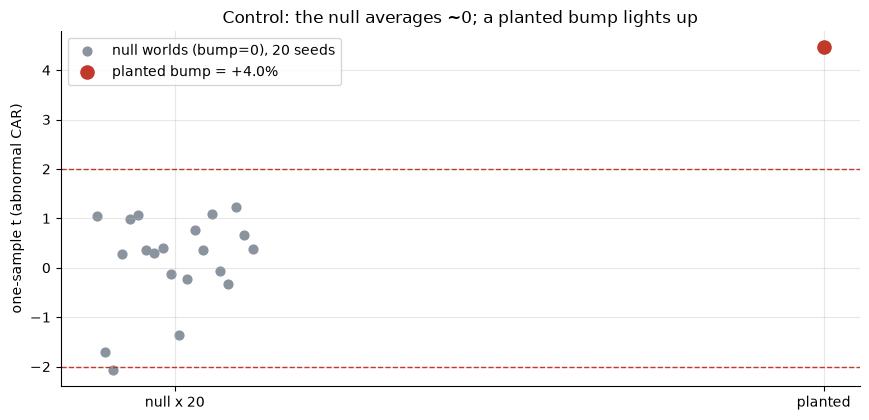

null: mean t = +0.15 (sd 0.93), |t|>=2 in 1/20 seeds  |  planted t = +4.46


In [6]:
null_ts = []
for s_ in range(20):
    close, em = data.synthetic_world(bump=0.0, seed=741 + s_)
    null_ts.append(st.synthetic_detect(close, em, k=R['K'])['t'])
null_ts = np.asarray(null_ts)
close, em = data.synthetic_world(bump=0.04, seed=741)
planted_t = st.synthetic_detect(close, em, k=R['K'])['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted bump = +4.0%')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (abnormal CAR)')
ax.set_title('Control: the null averages ~0; a planted bump lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.15 (sd 0.93) and crosses |t| ≥ 2 in just 1/20 seeds — exactly the ~5% false-positive rate a correct 5% test *should* show, never a systematic misfire; a planted +4% spring bump reads t = 4.46. The machinery is unbiased, so the real-tape t = +0.37 is a genuine null. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — cicada-spring abnormal CAR **+0.39%**, one-sample t = **+0.37** (n=24); random-year placebo **p = 0.165**; Welch vs non-cicada springs t = **+0.87**; 1-month window t = +0.20; no event-anatomy offset clears |t| ≥ 2. The 75% up-rate and the 5/5 famous-brood cut are base-rate and selection artifacts.
- **Tradability `MIRAGE`** — the timer's +2.25 t-vs-zero is pure equity beta; the excess over the every-spring baseline is **+60 bps at t = 0.56** (gross), fading to +40 bps net of 10 bps costs. No alpha to charge costs against.
- **"Cicada indicator?" `BUSTED`** — a brood emerges in **24 of 30** recent years, so "cicada years" are nearly the whole calendar. The pattern that survives is a coin flip on top of drift — exactly what a mechanism-free fixed calendar should produce.

## 6 · Going further

- **This study is a negative control by design.** Its value is precisely that the apparatus returns nothing on a pattern with no mechanism — the reassurance that the desk's *positive* verdicts elsewhere aren't the same machinery hallucinating. A green stamp here would be a bug report.
- **The generalisable lesson.** Any fixed, evocative calendar can be mined for a small-n streak in a secular bull market; the two failure modes this notebook isolates — reading an up-rate against 50% instead of the equity base rate, and grading a timer on gross instead of excess-over-baseline — are how almanac indicators get sold. The antidote is out-of-sample data, a pre-registered window, and alpha-not-beta accounting.
- **Dedup map:** [707-plane-crash-effect](../../707-plane-crash-effect/) and [708-eurovision-effect](../../708-eurovision-effect/) share this exact apparatus on real sentiment triggers; Cicada-Brood is the null control that calibrates them.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*